In [482]:
import math
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.covariance import LedoitWolf
from sklearn.ensemble import HistGradientBoostingRegressor

In [483]:
N_ASSETS = 25
TICKS_PER_DAY = 30
TRADING_DAYS_PER_YEAR = 252
IMPACT_MULT = 2.5
DT_YEAR = 1.0 / (TRADING_DAYS_PER_YEAR * TICKS_PER_DAY)

TRAIN_YEARS = 4
HOLDOUT_YEARS = 1
TRAIN_TICKS = TRAIN_YEARS * TRADING_DAYS_PER_YEAR * TICKS_PER_DAY
HOLDOUT_TICKS = HOLDOUT_YEARS * TRADING_DAYS_PER_YEAR * TICKS_PER_DAY

ASSET_COLUMNS = tuple(f"A{i:02d}" for i in range(N_ASSETS))

PRICES_PATH = "prices.csv"
META_PATH = "meta.csv"

@dataclass(frozen=True)
class PublicMeta:
    sector_id: np.ndarray
    spread_bps: np.ndarray
    borrow_bps_annual: np.ndarray


def load_prices(path: str = PRICES_PATH) -> np.ndarray:
    df = pd.read_csv(path, index_col="tick")
    return df[list(ASSET_COLUMNS)].to_numpy(dtype=float)


def load_meta(path: str = META_PATH) -> PublicMeta:
    df = pd.read_csv(path)
    return PublicMeta(
        sector_id=df["sector_id"].to_numpy(dtype=int),
        spread_bps=df["spread_bps"].to_numpy(dtype=float),
        borrow_bps_annual=df["borrow_bps_annual"].to_numpy(dtype=float),
    )

In [484]:
def project_to_gross_limit(w: np.ndarray) -> np.ndarray:
    w = np.asarray(w, dtype=float).copy()
    gross = float(np.sum(np.abs(w)))
    if not np.isfinite(gross):
        return np.zeros_like(w)
    if gross > 1.0:
        w /= gross
    return w


def fit_covariances(train_ret: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    x = train_ret.values
    cov_sample = np.cov(x, rowvar=False)
    lw = LedoitWolf().fit(x)
    cov_lw = lw.covariance_
    return cov_sample, cov_lw


def risk_parity_weights(cov: np.ndarray, tol: float = 1e-8, max_iter: int = 1000) -> np.ndarray:
    n = cov.shape[0]
    w = np.ones(n, dtype=float) / n
    eps = 1e-12

    for _ in range(max_iter):
        marginal = cov @ w
        rc = w * marginal
        port_var = float(w @ marginal)

        if port_var <= eps:
            return np.ones(n, dtype=float) / n

        target = port_var / n
        denom = np.maximum(rc, eps)
        w_new = w * (target / denom)
        w_new = np.maximum(w_new, eps)
        w_new /= w_new.sum()

        if np.linalg.norm(w_new - w, ord=1) < tol:
            w = w_new
            break
        w = w_new

    return w


def annualized_sharpe(daily_returns: np.ndarray) -> float:
    x = np.asarray(daily_returns, dtype=float)
    mu = float(np.mean(x))
    sd = float(np.std(x, ddof=1))
    if not np.isfinite(sd) or sd < 1e-12:
        return -np.inf if mu <= 0 else np.inf
    return math.sqrt(TRADING_DAYS_PER_YEAR) * mu / sd

In [485]:
def _transaction_cost(spread: np.ndarray, delta_weights: np.ndarray, impact_mult: float = IMPACT_MULT):
    linear = float(np.sum((spread / 2.0) * np.abs(delta_weights)))
    quadratic = float(np.sum((impact_mult * spread) * (delta_weights ** 2)))
    return linear, quadratic


def _hold_fixed_weights_one_day(
    wealth: float,
    weights: np.ndarray,
    logret: np.ndarray,
    borrow: np.ndarray,
    *,
    day: int,
) -> float:
    t0 = day * TICKS_PER_DAY
    t_begin = t0 + 1 if day == 0 else t0

    for t in range(t_begin, t0 + TICKS_PER_DAY):
        pnl = float(np.sum(weights * (np.exp(logret[t]) - 1.0)))
        borrow_cost = float(np.sum(np.maximum(-weights, 0.0) * borrow) * DT_YEAR)
        wealth *= 1.0 + pnl - borrow_cost

    return wealth


def _history_through_day(train_prices: np.ndarray, hold_prices: np.ndarray, day: int) -> np.ndarray:
    cutoff = (day + 1) * TICKS_PER_DAY
    return np.vstack([train_prices, hold_prices[:cutoff]])


def run_backtest(train_prices, hold_prices, strategy, meta: PublicMeta) -> dict:
    train_prices = np.asarray(train_prices, dtype=float)
    hold_prices = np.asarray(hold_prices, dtype=float)

    spread = np.asarray(meta.spread_bps, dtype=float) / 1e4
    borrow = np.asarray(meta.borrow_bps_annual, dtype=float) / 1e4

    strategy.fit(train_prices, meta, ticks_per_day=TICKS_PER_DAY)
    weights = project_to_gross_limit(strategy.get_weights(train_prices, meta, day=0))

    wealth = 1.0
    entry_linear, entry_quadratic = _transaction_cost(spread, weights, IMPACT_MULT)
    wealth *= 1.0 - (entry_linear + entry_quadratic)

    logret = np.zeros_like(hold_prices, dtype=float)
    logret[1:, :] = np.log(hold_prices[1:, :] / hold_prices[:-1, :])

    n_days = hold_prices.shape[0] // TICKS_PER_DAY
    daily_returns = np.zeros(n_days)
    daily_costs = np.zeros(n_days + 1)
    daily_costs[0] = entry_linear + entry_quadratic

    weights_history = [weights.copy()]

    for day in range(n_days):
        wealth_start = wealth
        wealth = _hold_fixed_weights_one_day(wealth, weights, logret, borrow, day=day)

        if wealth <= 0 or not np.isfinite(wealth):
            daily_returns[day:] = -1.0
            return {
                "daily_returns": daily_returns,
                "daily_costs": daily_costs[:day + 1],
                "weights_history": np.array(weights_history),
                "blown_up": True,
            }

        history = _history_through_day(train_prices, hold_prices, day)
        target = project_to_gross_limit(strategy.get_weights(history, meta, day=day + 1))

        delta = target - weights
        linear, quadratic = _transaction_cost(spread, delta, IMPACT_MULT)
        trade_cost = linear + quadratic

        wealth *= 1.0 - trade_cost
        daily_costs[day + 1] = trade_cost
        daily_returns[day] = wealth / wealth_start - 1.0

        weights = target
        weights_history.append(weights.copy())

    return {
        "daily_returns": daily_returns,
        "daily_costs": daily_costs,
        "weights_history": np.array(weights_history),
        "blown_up": False,
    }

In [486]:
prices = np.asarray(load_prices(PRICES_PATH), dtype=float)
meta = load_meta(META_PATH)

train_prices = prices[:TRAIN_TICKS]
hold_prices = prices[TRAIN_TICKS:TRAIN_TICKS + HOLDOUT_TICKS]

print(prices.shape)
print(train_prices.shape)
print(hold_prices.shape)

(37800, 25)
(30240, 25)
(7560, 25)


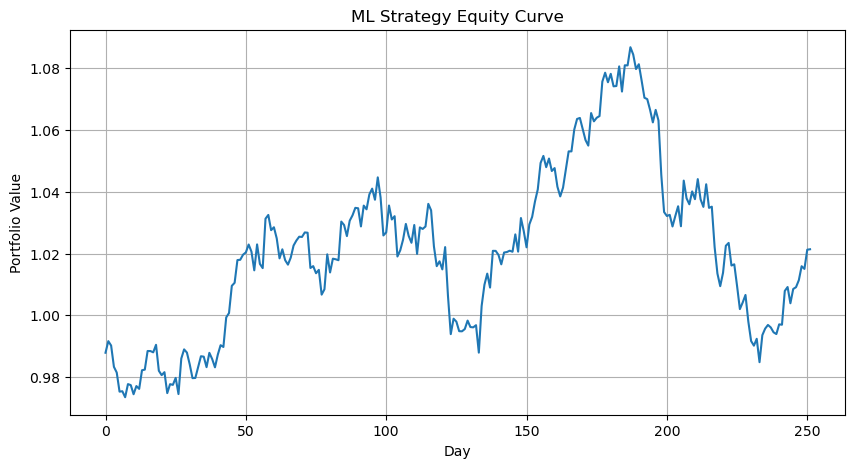

In [487]:
equity = np.cumprod(1.0 + daily_returns)

plt.figure(figsize=(10, 5))
plt.plot(equity)
plt.title("ML Strategy Equity Curve")
plt.xlabel("Day")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()

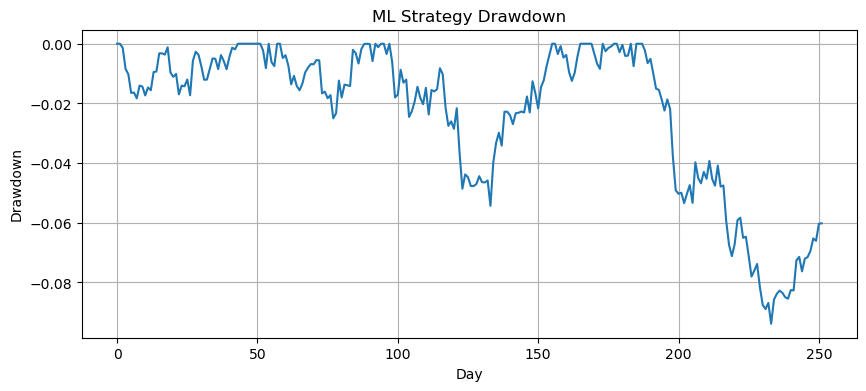

Max drawdown: -0.09381740582600817


In [488]:
cummax = np.maximum.accumulate(equity)
drawdown = equity / cummax - 1.0

plt.figure(figsize=(10, 4))
plt.plot(drawdown)
plt.title("ML Strategy Drawdown")
plt.xlabel("Day")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

print("Max drawdown:", drawdown.min())

In [489]:
final_weights = weights_history[-1]
weights_df = pd.DataFrame({
    "asset": ASSET_COLUMNS,
    "sector": meta.sector_id,
    "spread_bps": meta.spread_bps,
    "borrow_bps_annual": meta.borrow_bps_annual,
    "weight": final_weights,
}).sort_values("weight", ascending=False)

weights_df

,asset,sector,spread_bps,borrow_bps_annual,weight
20,A20,2,4.0,160.0,0.093935
5,A05,4,4.0,78.0,0.061668
24,A24,4,2.0,138.0,0.060927
2,A02,2,2.0,124.0,0.044540
4,A04,3,2.0,44.0,0.038314
6,A06,4,4.0,72.0,0.032465
9,A09,3,4.0,42.0,0.024372
13,A13,1,2.0,116.0,0.023709
0,A00,2,7.0,121.0,0.021736
7,A07,0,7.0,48.0,0.019520


In [622]:
from sklearn.linear_model import Ridge

class FastMLStrategy:
    """
    Train-once ML alpha:
    - build training dataset from train_prices in fit()
    - fit one Ridge model
    - in get_weights(), only predict current cross-section
    - blend with RP base
    """

    def __init__(self):
        self.ticks_per_day = TICKS_PER_DAY
        self.sector_id = None
        self.spread_bps = None
        self.borrow_bps_annual = None

        self.lookback_cov = 63
        self.min_days = 90

        self.beta = 0.60
        self.rebalance_rate = 0.2
        self.k_frac = 0.166

        from sklearn.linear_model import Ridge
        from sklearn.ensemble import HistGradientBoostingRegressor
        
        self.ridge_model = Ridge(alpha=1.0)
        
        self.hgb_model = HistGradientBoostingRegressor(
            max_depth=3,
            learning_rate=0.05,
            max_iter=100,
            l2_regularization=1.0,
            random_state=42
        )
        
        self.ridge_fitted = False
        self.hgb_fitted = False

    def fit(self, train_prices: np.ndarray, meta: PublicMeta, **kwargs) -> None:
        self.ticks_per_day = int(kwargs.get("ticks_per_day", TICKS_PER_DAY))
        self.sector_id = np.asarray(meta.sector_id, dtype=int)
        self.spread_bps = np.asarray(meta.spread_bps, dtype=float)
        self.borrow_bps_annual = np.asarray(meta.borrow_bps_annual, dtype=float)
        self.prev_weights = None
    
        # ADD THIS: how many daily observations were available in training
        self.train_days_available = len(self._daily_returns_df(train_prices))
    
        daily_ret = self._daily_returns_df(train_prices)
        X, y = self._build_dataset(daily_ret)
        
        if X is not None and len(X) > 100:
            self.ridge_model.fit(X, y)
            self.ridge_fitted = True
        
            self.hgb_model.fit(X, y)
            self.hgb_fitted = True
        else:
            self.ridge_fitted = False
            self.hgb_fitted = False

    def _daily_closes(self, price_history) -> np.ndarray:
        prices = np.asarray(price_history, dtype=float)
        n_ticks = prices.shape[0]
        n_days = n_ticks // self.ticks_per_day
        if n_days == 0:
            return np.empty((0, prices.shape[1]), dtype=float)

        close_idx = np.arange(
            self.ticks_per_day - 1,
            n_days * self.ticks_per_day,
            self.ticks_per_day,
        )
        return prices[close_idx]

    def _daily_returns_df(self, price_history) -> pd.DataFrame:
        closes = self._daily_closes(price_history)
        if closes.shape[0] <= 1:
            return pd.DataFrame(np.empty((0, closes.shape[1])), columns=ASSET_COLUMNS)

        ret = closes[1:] / closes[:-1] - 1.0
        return pd.DataFrame(ret, columns=ASSET_COLUMNS)

    def _rolling_mean(self, arr: np.ndarray, start: int, end: int) -> float:
        x = arr[start:end]
        if len(x) == 0:
            return 0.0
        return float(np.mean(x))

    def _rolling_std(self, arr: np.ndarray, start: int, end: int) -> float:
        x = arr[start:end]
        if len(x) <= 1:
            return 1e-6
        v = float(np.std(x, ddof=1))
        return max(v, 1e-6)

    def _build_dataset(self, daily_ret: pd.DataFrame):
        R = daily_ret.values
        n_days, n_assets = R.shape

        if n_days < 70:
            return None, None

        rows = []
        y = []

        spread_frac = self.spread_bps / 1e4
        borrow_frac = self.borrow_bps_annual / 1e4
        sectors = self.sector_id

        for t in range(60, n_days - 1):
            market_1 = np.mean(R[t - 1])
            market_5 = np.mean(R[t - 5:t])
            market_20 = np.mean(R[t - 20:t])

            for i in range(n_assets):
                r_i = R[:, i]

                ret_1 = r_i[t - 1]
                ret_5 = self._rolling_mean(r_i, t - 5, t)
                ret_10 = self._rolling_mean(r_i, t - 10, t)
                ret_20 = self._rolling_mean(r_i, t - 20, t)
                ret_60 = self._rolling_mean(r_i, t - 60, t)

                vol_5 = self._rolling_std(r_i, t - 5, t)
                vol_20 = self._rolling_std(r_i, t - 20, t)
                vol_60 = self._rolling_std(r_i, t - 60, t)

                sec = sectors[i]
                sec_idx = np.where(sectors == sec)[0]

                sec_ret_5 = float(np.mean(R[t - 5:t, sec_idx]))
                sec_ret_20 = float(np.mean(R[t - 20:t, sec_idx]))
                sec_ret_60 = float(np.mean(R[t - 60:t, sec_idx]))

                rel_5 = ret_5 - sec_ret_5
                rel_20 = ret_20 - sec_ret_20
                rel_60 = ret_60 - sec_ret_60

                rows.append([
                    ret_1, ret_5, ret_10, ret_20, ret_60,
                    vol_5, vol_20, vol_60,
                    rel_5, rel_20, rel_60,
                    market_1, market_5, market_20,
                    spread_frac[i], borrow_frac[i], float(sec),
                ])
                y.append(R[t + 1, i])

        return np.asarray(rows, dtype=float), np.asarray(y, dtype=float)

    def _build_current_feature_matrix(self, daily_ret: pd.DataFrame) -> np.ndarray:
        R = daily_ret.values
        n_days, n_assets = R.shape

        spread_frac = self.spread_bps / 1e4
        borrow_frac = self.borrow_bps_annual / 1e4
        sectors = self.sector_id

        t = n_days
        market_1 = np.mean(R[t - 1])
        market_5 = np.mean(R[t - 5:t])
        market_20 = np.mean(R[t - 20:t])

        rows = []

        for i in range(n_assets):
            r_i = R[:, i]

            ret_1 = r_i[t - 1]
            ret_5 = self._rolling_mean(r_i, t - 5, t)
            ret_10 = self._rolling_mean(r_i, t - 10, t)
            ret_20 = self._rolling_mean(r_i, t - 20, t)
            ret_60 = self._rolling_mean(r_i, t - 60, t)

            vol_5 = self._rolling_std(r_i, t - 5, t)
            vol_20 = self._rolling_std(r_i, t - 20, t)
            vol_60 = self._rolling_std(r_i, t - 60, t)

            sec = sectors[i]
            sec_idx = np.where(sectors == sec)[0]

            sec_ret_5 = float(np.mean(R[t - 5:t, sec_idx]))
            sec_ret_20 = float(np.mean(R[t - 20:t, sec_idx]))
            sec_ret_60 = float(np.mean(R[t - 60:t, sec_idx]))

            rel_5 = ret_5 - sec_ret_5
            rel_20 = ret_20 - sec_ret_20
            rel_60 = ret_60 - sec_ret_60

            rows.append([
                ret_1, ret_5, ret_10, ret_20, ret_60,
                vol_5, vol_20, vol_60,
                rel_5, rel_20, rel_60,
                market_1, market_5, market_20,
                spread_frac[i], borrow_frac[i], float(sec),
            ])

        return np.asarray(rows, dtype=float)

    def _robust_cs_score(self, x: np.ndarray) -> np.ndarray:
        """
        Cross-sectional robust score:
        - de-mean
        - scale by MAD-like percentile spread
        - clip extremes
        """
        x = np.asarray(x, dtype=float)
        x = x - np.mean(x)
    
        q10, q90 = np.percentile(x, [10, 90])
        scale = max(q90 - q10, 1e-6)
    
        z = x / scale
        z = np.clip(z, -3.0, 3.0)
        return z
    
    def _build_alpha(self, daily_ret: pd.DataFrame) -> np.ndarray:
        X_now = self._build_current_feature_matrix(daily_ret)
    
        preds = []
    
        if self.ridge_fitted:
            pred_ridge = self.ridge_model.predict(X_now)
            preds.append(0.6 * pred_ridge)
    
        if self.hgb_fitted:
            pred_hgb = self.hgb_model.predict(X_now)
            preds.append(0.4 * pred_hgb)
    
        if not preds:
            return np.zeros(N_ASSETS, dtype=float)
    
        pred = np.sum(preds, axis=0)
    
        # cross-sectional de-mean
        alpha = pred - np.mean(pred)
    
        # SINGLE clean regularization (not repeated)
        vol = daily_ret.std(axis=0).values + 1e-6
        alpha = alpha / vol
    
        # LIGHT shrink (keep dispersion)
        alpha = 0.5 * alpha
    
        # VERY mild clipping (do NOT kill tails)
        alpha = np.tanh(1.2 * alpha)
    
        return alpha
    def get_weights(self, price_history, meta: PublicMeta, day: int) -> np.ndarray:
        daily_ret = self._daily_returns_df(price_history)
        n_days = len(daily_ret)
    
        if n_days < self.min_days:
            w = np.ones(N_ASSETS, dtype=float) / N_ASSETS
            self.prev_weights = w.copy()
            return w
    
        cov_lb = min(self.lookback_cov, n_days)
        train_ret = daily_ret.iloc[-cov_lb:]
        _, cov_lw = fit_covariances(train_ret)
        w_rp = risk_parity_weights(cov_lw)
    
        alpha = self._build_alpha(daily_ret)
    
        if np.sum(np.abs(alpha)) < 1e-12:
            target = w_rp
        else:
            n = len(alpha)
            k = max(1, int(self.k_frac * n))
    
            sorted_idx = np.argsort(alpha)
            long_idx = sorted_idx[-k:]
            short_idx = sorted_idx[:k]
    
            alpha_filtered = np.zeros_like(alpha)
            alpha_filtered[long_idx] = alpha[long_idx]
            alpha_filtered[short_idx] = alpha[short_idx]
    
            alpha_overlay = alpha_filtered / (np.sum(np.abs(alpha_filtered)) + 1e-12)
    
            market_ret = daily_ret.mean(axis=1)
            trend_strength = np.mean(market_ret[-20:])
    
            if abs(trend_strength) < 0.001:
                beta_eff = self.beta * 0.8
            else:
                beta_eff = self.beta
    
            history_scale = min(1.0, self.train_days_available / 756.0)
            beta_eff = beta_eff * history_scale
    
            target = (1.0 - beta_eff) * w_rp + beta_eff * alpha_overlay
    
        target = project_to_gross_limit(target)
    
        if self.prev_weights is None:
            w = target
        else:
            w = (1.0 - self.rebalance_rate) * self.prev_weights + self.rebalance_rate * target
    
        w = project_to_gross_limit(w)
    
        if not np.all(np.isfinite(w)):
            w = np.ones(N_ASSETS, dtype=float) / N_ASSETS
    
        self.prev_weights = w.copy()
        return w

In [624]:
strategy = FastMLStrategy()
result = run_backtest(train_prices, hold_prices, strategy, meta)

dr = result["daily_returns"]
print("Sharpe:", annualized_sharpe(dr))
print("Return:", np.prod(1.0 + dr) - 1.0)
print("Cost:", np.sum(result["daily_costs"]))

Sharpe: 1.8208868329559837
Return: 0.156950161322863
Cost: 0.007787354091974412


In [625]:
def run_cv_fast_ml(prices: np.ndarray, meta: PublicMeta) -> pd.DataFrame:
    ticks_per_year = TRADING_DAYS_PER_YEAR * TICKS_PER_DAY
    total_years = prices.shape[0] // ticks_per_year

    rows = []

    for k in range(2, total_years):
        train_end = k * ticks_per_year
        test_end = (k + 1) * ticks_per_year
        if test_end > prices.shape[0]:
            break

        train_prices = prices[:train_end]
        hold_prices = prices[train_end:test_end]

        strategy = FastMLStrategy()
        result = run_backtest(train_prices, hold_prices, strategy, meta)

        dr = result["daily_returns"]
        eq = np.cumprod(1.0 + dr)
        dd = eq / np.maximum.accumulate(eq) - 1.0

        rows.append({
            "test_year": k,
            "sharpe": annualized_sharpe(dr),
            "total_return": np.prod(1.0 + dr) - 1.0,
            "max_drawdown": dd.min(),
            "total_cost": np.sum(result["daily_costs"]),
            "blew_up": result["blown_up"],
        })

    return pd.DataFrame(rows)

In [626]:
cv_results = run_cv_fast_ml(prices, meta)
cv_results

,test_year,sharpe,total_return,max_drawdown,total_cost,blew_up
0,2,0.182462,0.014087,-0.069649,0.005737,False
1,3,1.054851,0.084372,-0.057593,0.007815,False
2,4,1.820887,0.156950,-0.047628,0.007787,False


In [627]:
print("Mean Sharpe:", cv_results["sharpe"].mean())
print("Min Sharpe:", cv_results["sharpe"].min())
print("Std Sharpe:", cv_results["sharpe"].std())

Mean Sharpe: 1.0193997995249584
Min Sharpe: 0.18246169385424782
Std Sharpe: 0.8197876664126773
